# Assignment 2: Startup Profit Prediction
## Simple and Multiple Linear Regression
Dataset: 50_Startups.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error

# Load Dataset (Make sure 50_Startups.csv is in same folder)
df = pd.read_csv('50_Startups.csv')
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


## Simple Linear Regression (R&D Spend vs Profit)

In [2]:
X_simple = df[['R&D Spend']]
y = df['Profit']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_s = model_simple.predict(X_test_s)

print('R2 Score:', r2_score(y_test_s, y_pred_s))
print('MSE:', mean_squared_error(y_test_s, y_pred_s))

R2 Score: 0.9265108109341951
MSE: 59510962.80787996


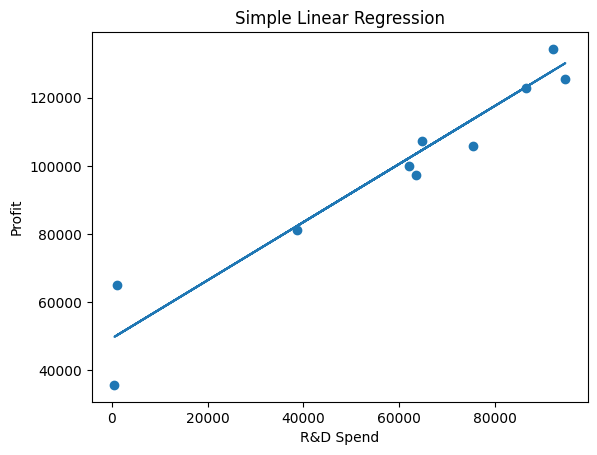

In [3]:
plt.figure()
plt.scatter(X_test_s, y_test_s)
plt.plot(X_test_s, y_pred_s)
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.title('Simple Linear Regression')
plt.show()

## Multiple Linear Regression (All Features)

In [4]:
X_multi = df.drop(columns=['Profit'])
y_multi = df['Profit']

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(drop='first'), ['State'])],
    remainder='passthrough'
)

X_multi_encoded = ct.fit_transform(X_multi)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi_encoded, y_multi, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

y_pred_m = model_multi.predict(X_test_m)

print('R2 Score:', r2_score(y_test_m, y_pred_m))
print('MSE:', mean_squared_error(y_test_m, y_pred_m))

R2 Score: 0.8987266414319832
MSE: 82010363.04501402


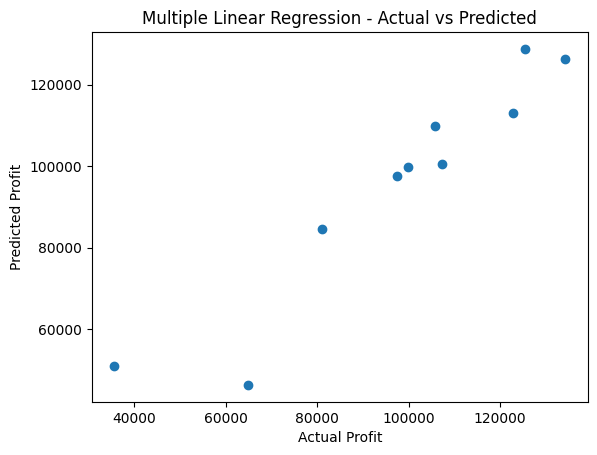

In [5]:
plt.figure()
plt.scatter(y_test_m, y_pred_m)
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Multiple Linear Regression - Actual vs Predicted')
plt.show()

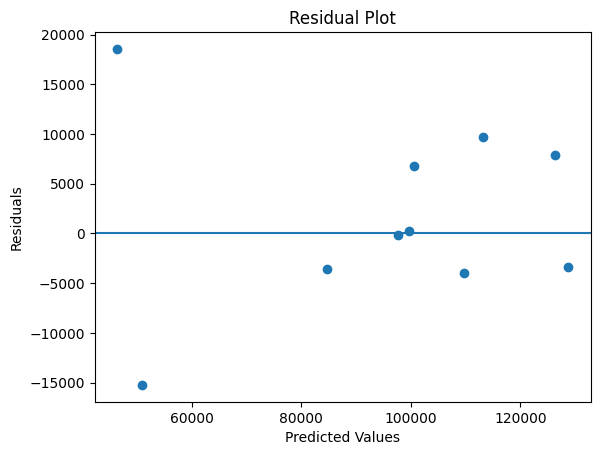

In [6]:
residuals = y_test_m - y_pred_m

plt.figure()
plt.scatter(y_pred_m, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()